In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

In [2]:
day = 2

In [3]:
df = pd.read_csv("data/round3/prices_round_3_day_2.csv", delimiter = ";")


In [4]:
df = df[df['product'].isin(['VOLCANIC_ROCK',
                            'VOLCANIC_ROCK_VOUCHER_9500',
                            'VOLCANIC_ROCK_VOUCHER_9750',
                            'VOLCANIC_ROCK_VOUCHER_10000',
                            'VOLCANIC_ROCK_VOUCHER_10250',
                            'VOLCANIC_ROCK_VOUCHER_10500'])]

In [5]:
# Step 1: Extract the VOLCANIC_ROCK mid_price per timestamp
rock_prices = df[df['product'] == 'VOLCANIC_ROCK'][['timestamp', 'mid_price']]
rock_prices = rock_prices.rename(columns={'mid_price': 'rock_mid_price'})

# Step 2: Filter out VOLCANIC_ROCK rows from the original DataFrame
df_filtered = df[df['product'] != 'VOLCANIC_ROCK']

# Step 3: Merge the rock mid prices into the filtered DataFrame
df_with_rock = df_filtered.merge(rock_prices, on='timestamp', how='left')

In [49]:
df_final = df_with_rock[['day','timestamp','product','mid_price','rock_mid_price']].copy()
df_final['product'] = df_with_rock['product'].str.extract(r'(\d+)').astype(float)
df_final = df_final.rename(columns={'product': 'strike', 'mid_price':'call_price'})


# properly calculate time to expiry, ensure day is set correctly with the dataset day
df_final['TTE'] = ((8 - day) / 365 - df_final['timestamp'] / 1000000 / 365)

# as mentioned in the hint
df_final['moneyness'] = np.log(df_final["strike"]/df_final["rock_mid_price"]) / np.sqrt(df_final['TTE'])

In [51]:
df_final

,day,timestamp,strike,call_price,rock_mid_price,TTE,moneyness
0,2,0,9750.0,469.5,10218.5,0.016438,-0.366054
1,2,0,9500.0,718.5,10218.5,0.016438,-0.568651
2,2,0,10250.0,63.5,10218.5,0.016438,0.024006
3,2,0,10000.0,233.5,10218.5,0.016438,-0.168586
4,2,0,10500.0,8.5,10218.5,0.016438,0.211957
...,...,...,...,...,...,...,...
49995,2,999900,10500.0,3.5,10166.5,0.013699,0.275774
49996,2,999900,10250.0,36.5,10166.5,0.013699,0.069887
49997,2,999900,10000.0,180.5,10166.5,0.013699,-0.141085
49998,2,999900,9750.0,417.5,10166.5,0.013699,-0.357398


In [53]:
def black_scholes_call(S, K, T, sigma):
    if T <= 0 or sigma <= 0:
        return max(S - K, 0)
    d1 = (np.log(S / K) + 0.5 * sigma**2 * T) / (sigma * math.sqrt(T))
    d2 = d1 - sigma * math.sqrt(T)
    N_d1 = 0.5 * (1 + math.erf(d1 / math.sqrt(2)))
    N_d2 = 0.5 * (1 + math.erf(d2 / math.sqrt(2)))
    return S * N_d1 - K * N_d2

In [55]:
def implied_vol_bisect(S, K, T, market_price, tol=1e-4, max_iter=100):
    low = 1e-6
    high = 5.0
    for _ in range(max_iter):
        mid = (low + high) / 2
        price = black_scholes_call(S, K, T, mid)
        if abs(price - market_price) < tol:
            return mid
        if price > market_price:
            high = mid
        else:
            low = mid
    return np.nan  # Could not converge

In [93]:
def compute_iv_row(row):
    return implied_vol_bisect(
        S=row['rock_mid_price'],
        K=row['strike'],
        T=row['TTE'],
        market_price=row['call_price']
    )

In [59]:
df_final['implied_vol'] = df_final.apply(compute_iv_row, axis=1)
df_final

,day,timestamp,strike,call_price,rock_mid_price,TTE,moneyness,implied_vol
0,2,0,9750.0,469.5,10218.5,0.016438,-0.366054,0.165483
1,2,0,9500.0,718.5,10218.5,0.016438,-0.568651,0.078126
2,2,0,10250.0,63.5,10218.5,0.016438,0.024006,0.149471
3,2,0,10000.0,233.5,10218.5,0.016438,-0.168586,0.158025
4,2,0,10500.0,8.5,10218.5,0.016438,0.211957,0.156877
...,...,...,...,...,...,...,...,...
49995,2,999900,10500.0,3.5,10166.5,0.013699,0.275774,0.161446
49996,2,999900,10250.0,36.5,10166.5,0.013699,0.069887,0.147963
49997,2,999900,10000.0,180.5,10166.5,0.013699,-0.141085,0.141534
49998,2,999900,9750.0,417.5,10166.5,0.013699,-0.357398,0.164219


In [129]:
def fit_iv_parabola(group):
    if len(group) < 3:
        return pd.Series({'a': np.nan, 'b': np.nan, 'c': np.nan})  # Need at least 3 points

    x = group['moneyness']
    y = group['implied_vol']
    
    # Drop NaNs
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    
    if len(x) < 3:
        return pd.Series({'a': np.nan, 'b': np.nan, 'c': np.nan})
    
    a, b, c = np.polyfit(x, y, deg=2)
    return pd.Series({'a': a, 'b': b, 'c': c})

def fit_iv_cubic(group):
    if len(group) < 4:
        return pd.Series({'a': np.nan, 'b': np.nan, 'c': np.nan, 'd': np.nan})

    x = group['moneyness']
    y = group['implied_vol']
    
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    
    if len(x) < 4:
        return pd.Series({'a': np.nan, 'b': np.nan, 'c': np.nan, 'd': np.nan})
    
    coeffs = np.polyfit(x, y, deg=3)
    return pd.Series({'a': coeffs[0], 'b': coeffs[1], 'c': coeffs[2], 'd': coeffs[3]})

def fit_iv_quartic(group):
    if len(group) < 5:
        return pd.Series({f'coef_{i}': np.nan for i in range(5)})

    x = group['moneyness']
    y = group['implied_vol']
    
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    
    if len(x) < 5:
        return pd.Series({f'coef_{i}': np.nan for i in range(5)})
    
    coeffs = np.polyfit(x, y, deg=4)
    return pd.Series({f'coef_{i}': coeffs[i] for i in range(5)})

In [101]:
# quadratic, could be under fit or better than cubic
"""
iv_fits = df_final.groupby('timestamp').apply(fit_iv_parabola).reset_index()
df_with_fit = df_final.merge(iv_fits, on='timestamp', how='left')

# You can compute the fitted IV for each row:
df_final['fitted_iv'] = (
    df_with_fit['a'] * df_with_fit['moneyness']**2 +
    df_with_fit['b'] * df_with_fit['moneyness'] +
    df_with_fit['c']
)

df_final['iv_deviation'] = df_final['implied_vol'] - df_final['fitted_iv']
df_final
"""

,day,timestamp,strike,call_price,rock_mid_price,TTE,moneyness,implied_vol,fitted_iv,iv_deviation
0,2,0,9750.0,469.5,10218.5,0.016438,-0.366054,0.165483,0.139889,0.025593
1,2,0,9500.0,718.5,10218.5,0.016438,-0.568651,0.078126,0.089487,-0.011361
2,2,0,10250.0,63.5,10218.5,0.016438,0.024006,0.149471,0.166783,-0.017313
3,2,0,10000.0,233.5,10218.5,0.016438,-0.168586,0.158025,0.165044,-0.007019
4,2,0,10500.0,8.5,10218.5,0.016438,0.211957,0.156877,0.146778,0.010099
...,...,...,...,...,...,...,...,...,...,...
49995,2,999900,10500.0,3.5,10166.5,0.013699,0.275774,0.161446,0.151908,0.009539
49996,2,999900,10250.0,36.5,10166.5,0.013699,0.069887,0.147963,0.161731,-0.013768
49997,2,999900,10000.0,180.5,10166.5,0.013699,-0.141085,0.141534,0.155724,-0.014190
49998,2,999900,9750.0,417.5,10166.5,0.013699,-0.357398,0.164219,0.132674,0.031545


In [137]:
# cubic,  risk of fitting
iv_fits_cubic = df_final.groupby('timestamp').apply(fit_iv_cubic).reset_index()
df_final = df_final.merge(iv_fits_cubic, on='timestamp', how='left')

# Recompute fitted IV
df_final['fitted_iv'] = (
    df_final['a'] * df_final['moneyness']**3 +
    df_final['b'] * df_final['moneyness']**2 +
    df_final['c'] * df_final['moneyness'] +
    df_final['d']
)

# New deviation
df_final['iv_deviation'] = df_final['implied_vol'] - df_final['fitted_iv']

/var/folders/4b/jybwcwfx3dg38xf8jnf2pzww0000gn/T/ipykernel_7436/3940237129.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  iv_fits_cubic = df_final.groupby('timestamp').apply(fit_iv_cubic).reset_index()


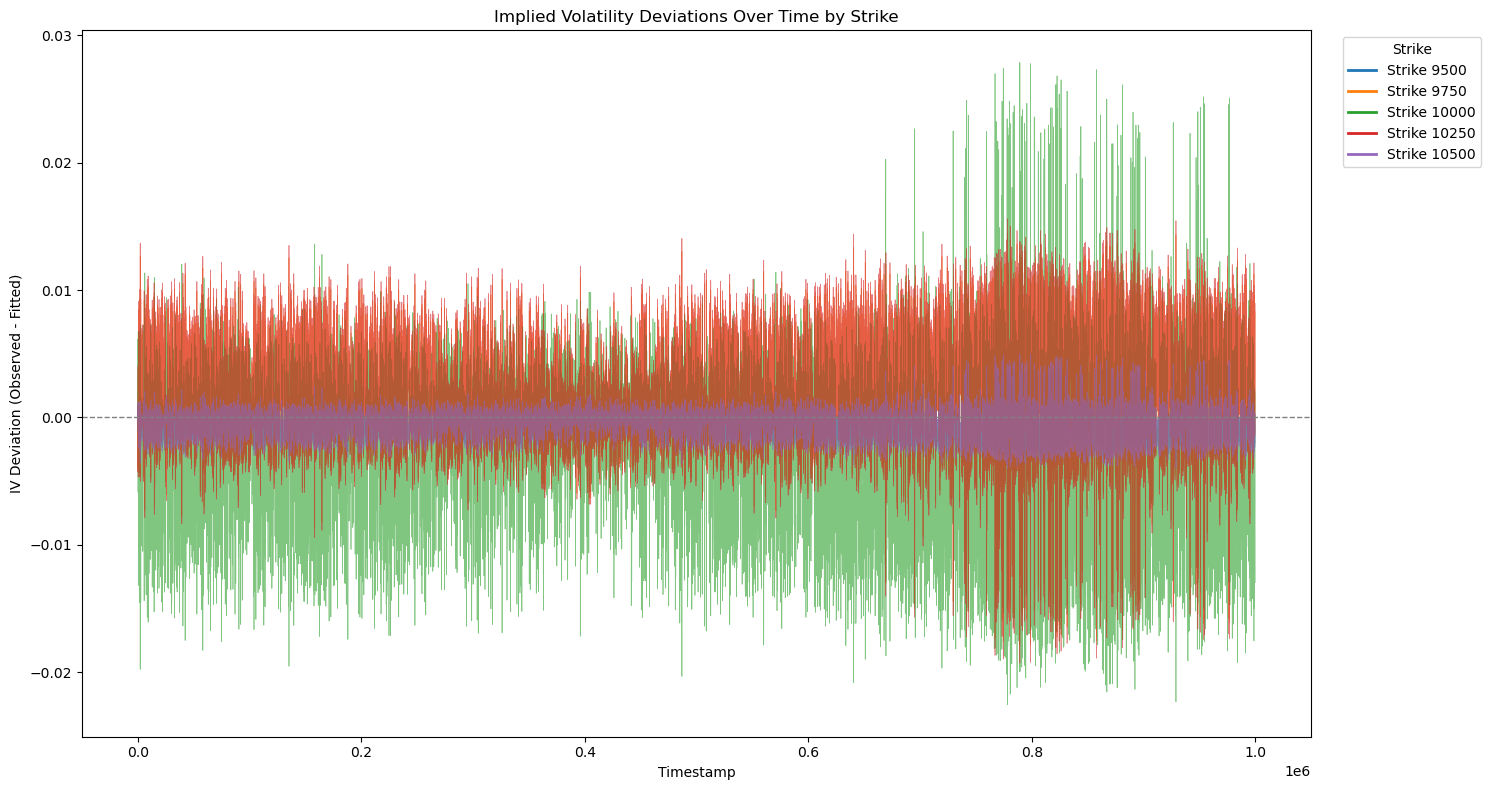

In [141]:
from matplotlib.lines import Line2D

# Get unique strikes and assign colors
unique_strikes = sorted(df_final['strike'].unique())
num_colors = len(unique_strikes)
cmap = plt.get_cmap('tab10' if num_colors <= 10 else 'tab20')
colors = [cmap(i) for i in range(num_colors)]


# Plot
plt.figure(figsize=(15, 8))
legend_elements = []

for strike, color in zip(unique_strikes, colors):
    subset = df_final[df_final['strike'] == strike]
    plt.plot(subset['timestamp'], subset['iv_deviation'], label=f'Strike {int(strike)}', color=color, linewidth = 0.5, alpha = 0.6)

    legend_elements.append(Line2D([0], [0], color=color, lw=2, label=f'Strike {int(strike)}'))

plt.axhline(0, linestyle='--', color='gray', linewidth=1)
plt.xlabel('Timestamp')
plt.ylabel('IV Deviation (Observed - Fitted)')
plt.title('Implied Volatility Deviations Over Time by Strike')
plt.legend(handles=legend_elements, title='Strike', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

Remember this hint:

"I also call fitted v_t(m_t=0) the base IV and I have identified interesting patterns in timeseries of base IV."

In [146]:
iv_fits_cubic['d']

0       0.147030
1       0.152703
2       0.148765
3       0.148300
4       0.153586
          ...   
9995    0.143777
9996    0.147904
9997    0.145042
9998    0.147646
9999    0.142216
Name: d, Length: 10000, dtype: float64

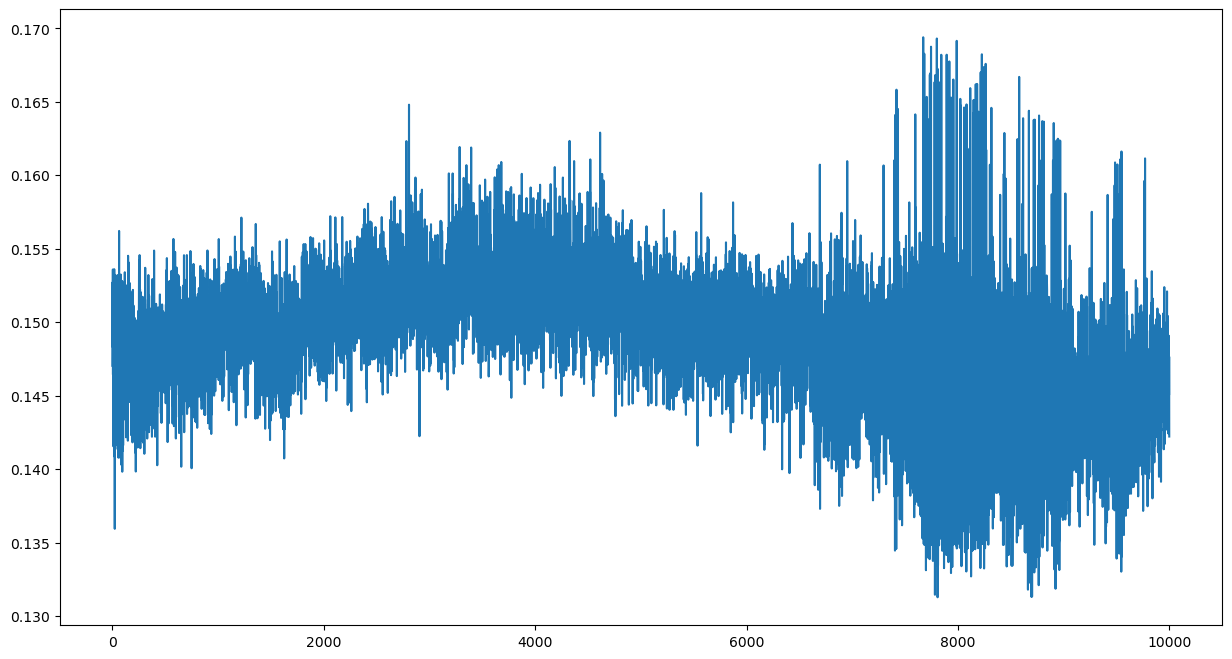

In [148]:
plt.figure(figsize=(15, 8))
plt.plot(iv_fits_cubic.index, iv_fits_cubic['d'])
plt.show()

# is this sinusodial?